# DermaMNIST Ensemble Study, Evaluation and Plots

## Setup

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                              roc_auc_score, precision_score, recall_score, f1_score,
                              average_precision_score, log_loss)
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import label_binarize
from scipy.signal import find_peaks
from scipy.stats import gaussian_kde

import warnings
warnings.filterwarnings('ignore')

# Set seeds for reproducibility of meta-learner
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.keras.utils.set_random_seed(SEED)

## Configuration

In [2]:
DATASET = 'dermamnist'  # Change to: 'bloodmnist', 'breastmnist', 'dermamnist', 'organamnist'

# Dataset-specific configuration
DATASET_CONFIG = {
    'bloodmnist':   {'n_classes': 8,  'figure_number': 3},
    'breastmnist':  {'n_classes': 2,  'figure_number': 4},
    'dermamnist':   {'n_classes': 7,  'figure_number': 5},
    'organamnist':  {'n_classes': 11, 'figure_number': 6},
}

n_classes = DATASET_CONFIG[DATASET]['n_classes']
FIGURE_NUMBER = DATASET_CONFIG[DATASET]['figure_number']

INPUT_DIR = f"./{DATASET}_outputs"  
OUTPUT_DIR = f"./{DATASET}_results"  
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Class names mapping
CLASS_NAMES_MAP = {
    'bloodmnist': ['basophil', 'eosinophil', 'erythroblast', 'immature granulocyte',
                   'lymphocyte', 'monocyte', 'neutrophil', 'platelet'],
    'breastmnist': ['malignant', 'normal/benign'],
    'dermamnist': ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc'],
    'organamnist': ['bladder', 'femur-L', 'femur-R', 'heart', 'kidney-L', 'kidney-R',
                    'liver', 'lung-L', 'lung-R', 'pancreas', 'spleen']
}

CLASS_NAMES_MAP_4CM = {
    'bloodmnist': ['basophil', 'eosinophil', 'erythroblast', 'immature \ngranulocyte',
                   'lymphocyte', 'monocyte', 'neutrophil', 'platelet'],
    'breastmnist': ['malignant', 'normal/benign'],
    'dermamnist': ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc'],
    'organamnist': ['bladder', 'femur-L', 'femur-R', 'heart', 'kidney-L', 'kidney-R',
                    'liver', 'lung-L', 'lung-R', 'pancreas', 'spleen']
}
CLASS_NAMES = CLASS_NAMES_MAP[DATASET]
CLASS_NAMES_4CM = CLASS_NAMES_MAP_4CM[DATASET]

# Meta-learner hyperparameters
DROPOUT_META = 0.5
META_BATCH_SIZE = 16
META_EPOCHS = 50
META_PATIENCE = 5

print(f"Dataset: {DATASET}")
print(f"Number of classes: {n_classes}")
print(f"Input directory: {INPUT_DIR}")
print(f"Output directory: {OUTPUT_DIR}")

Dataset: dermamnist
Number of classes: 7
Input directory: ./dermamnist_outputs
Output directory: ./dermamnist_results


## Load Predictions and Ground Truth

In [3]:
INDIVIDUAL_MODELS = ['ConvNeXtBase', 'ViT-Base', 'EfficientNetV2M', 'InceptionResNetV2']

test_preds = {}
val_preds = {}
for m in INDIVIDUAL_MODELS:
    test_preds[m] = np.load(f"{INPUT_DIR}/{m}_test_preds.npy")
    val_preds[m] = np.load(f"{INPUT_DIR}/{m}_val_preds.npy")
    print(f"{m}: test shape {test_preds[m].shape}, val shape {val_preds[m].shape}")

for fname in ['y_true_flat.npy', 'y_test_true.npy']:
    p = f"{INPUT_DIR}/{fname}"
    if os.path.exists(p):
        y_true_flat = np.load(p).flatten()
        print(f"\nLoaded ground truth from {fname}")
        break
else:
    raise FileNotFoundError(f"Could not find ground truth file in {INPUT_DIR}")

for fname in ['y_val_flat.npy', 'y_val_true.npy']:
    p = f"{INPUT_DIR}/{fname}"
    if os.path.exists(p):
        y_val_flat = np.load(p).flatten()
        print(f"Loaded val ground truth from {fname}")
        break
else:
    print("Reconstructing val ground truth from MedMNIST...")
    import medmnist
    from medmnist import INFO
    info = INFO[DATASET]
    DataClass = getattr(medmnist, info['python_class'])
    val_data = DataClass(split='val', download=True, size=28)
    y_val_flat = val_data.labels.flatten()

y_true_cat = to_categorical(y_true_flat, n_classes)
y_val_cat = to_categorical(y_val_flat, n_classes)
print(f"\nTest samples: {len(y_true_flat)}")
print(f"Val samples: {len(y_val_flat)}")

ConvNeXtBase: test shape (2005, 7), val shape (1003, 7)
ViT-Base: test shape (2005, 7), val shape (1003, 7)
EfficientNetV2M: test shape (2005, 7), val shape (1003, 7)
InceptionResNetV2: test shape (2005, 7), val shape (1003, 7)

Loaded ground truth from y_true_flat.npy
Reconstructing val ground truth from MedMNIST...

Test samples: 2005
Val samples: 1003


## Soft Voting Ensemble

In [4]:
print("="*70)
print("SOFT VOTING ENSEMBLE")
print("="*70)

soft_voting_probs = np.mean(np.array(list(test_preds.values())), axis=0)
np.save(f"{OUTPUT_DIR}/SoftVoting_test_preds.npy", soft_voting_probs)

acc = accuracy_score(y_true_flat, np.argmax(soft_voting_probs, axis=1))
print(f"Soft Voting Accuracy: {acc:.4f}")
print(f"Saved to: {OUTPUT_DIR}/SoftVoting_test_preds.npy")

SOFT VOTING ENSEMBLE
Soft Voting Accuracy: 0.9092
Saved to: ./dermamnist_results/SoftVoting_test_preds.npy


## Rigorous Stacking Ensemble

In [5]:
print("="*70)
print("RIGOROUS STACKING ENSEMBLE")
print("="*70)

# Build meta-training input from validation predictions
X_meta_train = np.concatenate([val_preds[m] for m in INDIVIDUAL_MODELS], axis=1)
X_meta_test = np.concatenate([test_preds[m] for m in INDIVIDUAL_MODELS], axis=1)

print(f"Meta-train shape: {X_meta_train.shape}")
print(f"Meta-test shape: {X_meta_test.shape}")

def build_meta_learner(input_dim, n_classes):
    inputs = layers.Input(shape=(input_dim,))
    x = layers.Dense(64, activation='relu')(inputs)
    x = layers.Dropout(DROPOUT_META)(x)
    x = layers.Dense(32, activation='relu')(x)
    outputs = layers.Dense(n_classes, activation='softmax')(x)
    return models.Model(inputs=inputs, outputs=outputs, name='Meta_Learner')

meta_model = build_meta_learner(X_meta_train.shape[1], n_classes)
meta_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

meta_model.fit(X_meta_train, y_val_cat,
               epochs=META_EPOCHS, batch_size=META_BATCH_SIZE,
               validation_split=0.1,
               callbacks=[callbacks.EarlyStopping(patience=META_PATIENCE, restore_best_weights=True)],
               verbose=1)

meta_model.save(f"{OUTPUT_DIR}/MetaLearner_{DATASET}.keras")
stacking_probs = meta_model.predict(X_meta_test, verbose=0)
np.save(f"{OUTPUT_DIR}/RigorousStacking_test_preds.npy", stacking_probs)

acc = accuracy_score(y_true_flat, np.argmax(stacking_probs, axis=1))
print(f"\nRigorous Stacking Accuracy: {acc:.4f}")
print(f"Saved to: {OUTPUT_DIR}/RigorousStacking_test_preds.npy")

RIGOROUS STACKING ENSEMBLE
Meta-train shape: (1003, 28)
Meta-test shape: (2005, 28)
Epoch 1/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6109 - loss: 1.4946 - val_accuracy: 0.7921 - val_loss: 0.9219
Epoch 2/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8093 - loss: 0.7236 - val_accuracy: 0.8119 - val_loss: 0.5514
Epoch 3/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8392 - loss: 0.5090 - val_accuracy: 0.8614 - val_loss: 0.4746
Epoch 4/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8681 - loss: 0.4677 - val_accuracy: 0.8515 - val_loss: 0.4353
Epoch 5/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8825 - loss: 0.4070 - val_accuracy: 0.8515 - val_loss: 0.4190
Epoch 6/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8814 - loss: 0.4024 - val_accuracy: 0.8713 - val_loss: 0.3988
Epoch 7/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8836 - loss: 0.3945 - val_accuracy: 0.8713 - val_loss: 0.3847
Epoch 8/50
57/57 ━━━━━━━━━━━━━━━━━

## Analysis Helper Functions

In [6]:
def print_confusion_matrix_table(cm, class_names, model_name):
    """Prints confusion matrix as a labeled pandas DataFrame."""
    cm_df = pd.DataFrame(cm,
                         index=[f"True_{c}" for c in class_names],
                         columns=[f"Pred_{c}" for c in class_names])
    print(f"\n--- {model_name} Confusion Matrix (Table) ---")
    print(cm_df.to_string())
    
    per_class_acc = cm.diagonal() / cm.sum(axis=1)
    print(f"\n--- Per-Class Recall ---")
    for i, c in enumerate(class_names):
        print(f"  Class {i} ({c}): {per_class_acc[i]:.4f} ({cm[i, i]}/{cm[i].sum()})")
    return cm_df


def analyze_entropy_peaks(entropy_correct, entropy_wrong, model_name,
                          n_points=1000):
    """
    Returns the single highest peak (mode) for correct and incorrect distributions.
    """
    if len(entropy_correct) < 2 or len(entropy_wrong) < 1:
        print(f"\n--- {model_name} ---\nInsufficient data for KDE")
        return None
    
    x_min = 0
    x_max = max(entropy_correct.max(), entropy_wrong.max()) + 0.1
    x_grid = np.linspace(x_min, x_max, n_points)
    
    # KDE for correct distribution - take global maximum
    kde_correct = gaussian_kde(entropy_correct)
    density_correct = kde_correct(x_grid)
    peak_correct_idx = int(np.argmax(density_correct))
    peak_correct_x = float(x_grid[peak_correct_idx])
    peak_correct_y = float(density_correct[peak_correct_idx])
    
    # KDE for wrong distribution - take global maximum
    if len(entropy_wrong) >= 2:
        kde_wrong = gaussian_kde(entropy_wrong)
        density_wrong = kde_wrong(x_grid)
        peak_wrong_idx = int(np.argmax(density_wrong))
        peak_wrong_x = float(x_grid[peak_wrong_idx])
        peak_wrong_y = float(density_wrong[peak_wrong_idx])
    else:
        # Edge case: single wrong sample
        density_wrong = np.zeros(n_points)
        peak_wrong_x = float(entropy_wrong[0])
        peak_wrong_y = 0.0
    
    print(f"\n--- {model_name} Entropy Distribution Analysis ---")
    print(f"Correct: n={len(entropy_correct)}, "
          f"mean={entropy_correct.mean():.4f}, "
          f"median={np.median(entropy_correct):.4f}, "
          f"std={entropy_correct.std():.4f}")
    print(f"Wrong:   n={len(entropy_wrong)}, "
          f"mean={entropy_wrong.mean():.4f}, "
          f"median={np.median(entropy_wrong):.4f}, "
          f"std={entropy_wrong.std():.4f}")
    
    print(f"\nHighest correct peak: entropy={peak_correct_x:.4f}, height={peak_correct_y:.4f}")
    print(f"Highest wrong peak:   entropy={peak_wrong_x:.4f}, height={peak_wrong_y:.4f}")
    
    return {
        'x_grid': x_grid.tolist(),
        'density_correct': density_correct.tolist(),
        'density_wrong': density_wrong.tolist(),
        'peaks_correct_x': [peak_correct_x],
        'peaks_correct_y': [peak_correct_y],
        'peaks_wrong_x': [peak_wrong_x],
        'peaks_wrong_y': [peak_wrong_y],
    }


def analyze_reliability_pairs(probs, y_pred, y_true, model_name, n_bins=10):
    is_correct = (y_pred == y_true).astype(int)
    pred_conf = np.max(probs, axis=1)
    
    prob_true, prob_pred = calibration_curve(is_correct, pred_conf, n_bins=n_bins, strategy='quantile')
    
    bins = np.quantile(pred_conf, np.linspace(0, 1, n_bins+1))
    bin_counts = []
    for i in range(len(bins)-1):
        mask = (pred_conf >= bins[i]) & (pred_conf <= bins[i+1])
        bin_counts.append(int(mask.sum()))
    
    print(f"\n--- {model_name} Reliability Diagram (Numerical) ---")
    print(f"{'Bin':<5} {'Confidence':<15} {'Accuracy':<15} {'Gap':<15} {'n_samples':<10}")
    print("-" * 65)
    for i in range(len(prob_pred)):
        gap = prob_pred[i] - prob_true[i]
        n = bin_counts[i] if i < len(bin_counts) else 0
        print(f"{i+1:<5} {prob_pred[i]:<15.4f} {prob_true[i]:<15.4f} {gap:<15.4f} {n:<10}")
    
    valid_counts = bin_counts[:len(prob_pred)]
    if sum(valid_counts) > 0:
        ece = np.sum(np.abs(np.array(prob_pred) - np.array(prob_true)) *
                     np.array(valid_counts) / sum(valid_counts))
    else:
        ece = 0
    print(f"\nExpected Calibration Error (ECE): {ece:.4f}")
    
    return {
        'confidence': prob_pred.tolist(),
        'accuracy': prob_true.tolist(),
        'gap': (prob_pred - prob_true).tolist(),
        'bin_counts': bin_counts,
        'ece': float(ece)
    }


def compute_all_metrics(probs, y_true_flat, y_true_cat, model_name):
    y_pred = np.argmax(probs, axis=1)
    return {
        'Model': model_name,
        'Accuracy': accuracy_score(y_true_flat, y_pred),
        'AUC_macro': roc_auc_score(y_true_cat, probs, multi_class='ovr', average='macro'),
        'AUC_weighted': roc_auc_score(y_true_cat, probs, multi_class='ovr', average='weighted'),
        'Precision_macro': precision_score(y_true_flat, y_pred, average='macro', zero_division=0),
        'Precision_weighted': precision_score(y_true_flat, y_pred, average='weighted', zero_division=0),
        'Recall_macro': recall_score(y_true_flat, y_pred, average='macro', zero_division=0),
        'Recall_weighted': recall_score(y_true_flat, y_pred, average='weighted', zero_division=0),
        'F1_macro': f1_score(y_true_flat, y_pred, average='macro', zero_division=0),
        'F1_weighted': f1_score(y_true_flat, y_pred, average='weighted', zero_division=0),
        'PR_AUC_macro': average_precision_score(y_true_cat, probs, average='macro'),
        'PR_AUC_weighted': average_precision_score(y_true_cat, probs, average='weighted'),
        'Log_Loss': log_loss(y_true_cat, probs)
    }

##  Master Evaluation Function

In [7]:
def to_json_safe(obj):
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, (np.float32, np.float64)):
        return float(obj)
    if isinstance(obj, (np.int32, np.int64)):
        return int(obj)
    return obj


def evaluate_model(probs, y_true_flat, y_true_cat, model_name, class_names, class_names_4cm, color='Blues'):
    print(f"\n{'='*70}\nEVALUATION: {model_name}\n{'='*70}")
    
    y_pred = np.argmax(probs, axis=1)
    
    # 1. Metrics
    metrics = compute_all_metrics(probs, y_true_flat, y_true_cat, model_name)
    print("\n--- Comprehensive Metrics ---")
    for k, v in metrics.items():
        if k != 'Model':
            print(f"  {k}: {v:.4f}")
    
    # 2. Classification Report
    print("\n--- Classification Report ---")
    print(classification_report(y_true_flat, y_pred, target_names=class_names, digits=4))
    
    # 3. Confusion Matrix
    cm = confusion_matrix(y_true_flat, y_pred)
    print_confusion_matrix_table(cm, class_names, model_name)
    
    # 4. Entropy Analysis 
    entropy = -np.sum(probs * np.log(probs + 1e-9), axis=1)
    correct_mask = (y_pred == y_true_flat)
    entropy_analysis = analyze_entropy_peaks(
        entropy[correct_mask], entropy[~correct_mask], model_name
    )
    
    # 5. Reliability Analysis
    reliability = analyze_reliability_pairs(probs, y_pred, y_true_flat, model_name)
    
    # 6. Diagnostic Plots WITH peak markers shown
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    
    # Confusion Matrix
    sns.heatmap(cm, annot=True, fmt='d', cmap=color, ax=axes[0],
                xticklabels=class_names_4cm, yticklabels=class_names_4cm)
    axes[0].set_title(f'{model_name} CM (Acc: {metrics["Accuracy"]:.2%})')
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('True')
    axes[0].tick_params(axis='x', labelsize=6)
    axes[0].tick_params(axis='y', labelsize=6)
    plt.setp(axes[0].get_xticklabels(), rotation=0, ha='center', rotation_mode='anchor')
    
    # Entropy Distribution WITH peak markers
    sns.kdeplot(entropy[correct_mask], label=f'Correct (n={correct_mask.sum()})',
                fill=True, color='#2166AC', ax=axes[1])
    sns.kdeplot(entropy[~correct_mask], label=f'Wrong (n={(~correct_mask).sum()})',
                fill=True, color='#D97B00', ax=axes[1])
    
    if entropy_analysis:
        for px, py in list(zip(entropy_analysis['peaks_correct_x'],
                                entropy_analysis['peaks_correct_y']))[:3]:
            axes[1].axvline(px, color='#2166AC', linestyle=':', alpha=0.6)
            axes[1].annotate(f'{px:.2f}\nh={py:.2f}', xy=(px, py),
                           xytext=(5, 5), textcoords='offset points',
                           fontsize=8, color='#2166AC')
        for px, py in list(zip(entropy_analysis['peaks_wrong_x'],
                                entropy_analysis['peaks_wrong_y']))[:3]:
            axes[1].axvline(px, color='#D97B00', linestyle=':', alpha=0.6)
            axes[1].annotate(f'{px:.2f}\nh={py:.2f}', xy=(px, py),
                           xytext=(5, -15), textcoords='offset points',
                           fontsize=8, color='#D97B00')
    
    axes[1].set_title(f'{model_name} Entropy')
    axes[1].set_xlabel('Shannon Entropy')
    axes[1].legend()
    
    # Reliability Diagram
    axes[2].plot(reliability['confidence'], reliability['accuracy'],
                 marker='o', label=model_name, color='purple')
    axes[2].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect')
    axes[2].set_title(f'{model_name} Reliability (ECE={reliability["ece"]:.4f})')
    axes[2].set_xlabel('Confidence')
    axes[2].set_ylabel('Accuracy')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/{model_name}_evaluation.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    # Save results
    results = {
        'metrics': {k: to_json_safe(v) for k, v in metrics.items()},
        'confusion_matrix': cm.tolist(),
        'entropy_analysis': entropy_analysis,
        'reliability': reliability
    }
    
    with open(f"{OUTPUT_DIR}/{model_name}_results.json", 'w') as f:
        json.dump(results, f, indent=2, default=to_json_safe)
    
    return results

## Evaluate All Models


EVALUATION: ConvNeXtBase

--- Comprehensive Metrics ---
  Accuracy: 0.8948
  AUC_macro: 0.9820
  AUC_weighted: 0.9771
  Precision_macro: 0.8506
  Precision_weighted: 0.8927
  Recall_macro: 0.7877
  Recall_weighted: 0.8948
  F1_macro: 0.8157
  F1_weighted: 0.8929
  PR_AUC_macro: 0.8934
  PR_AUC_weighted: 0.9451
  Log_Loss: 0.5129

--- Classification Report ---
              precision    recall  f1-score   support

       akiec     0.8113    0.6515    0.7227        66
         bcc     0.8200    0.7961    0.8079       103
         bkl     0.7686    0.8000    0.7840       220
          df     0.9444    0.7391    0.8293        23
         mel     0.7761    0.6996    0.7358       223
          nv     0.9411    0.9657    0.9533      1341
        vasc     0.8929    0.8621    0.8772        29

    accuracy                         0.8948      2005
   macro avg     0.8506    0.7877    0.8157      2005
weighted avg     0.8927    0.8948    0.8929      2005


--- ConvNeXtBase Confusion Matrix (Tabl

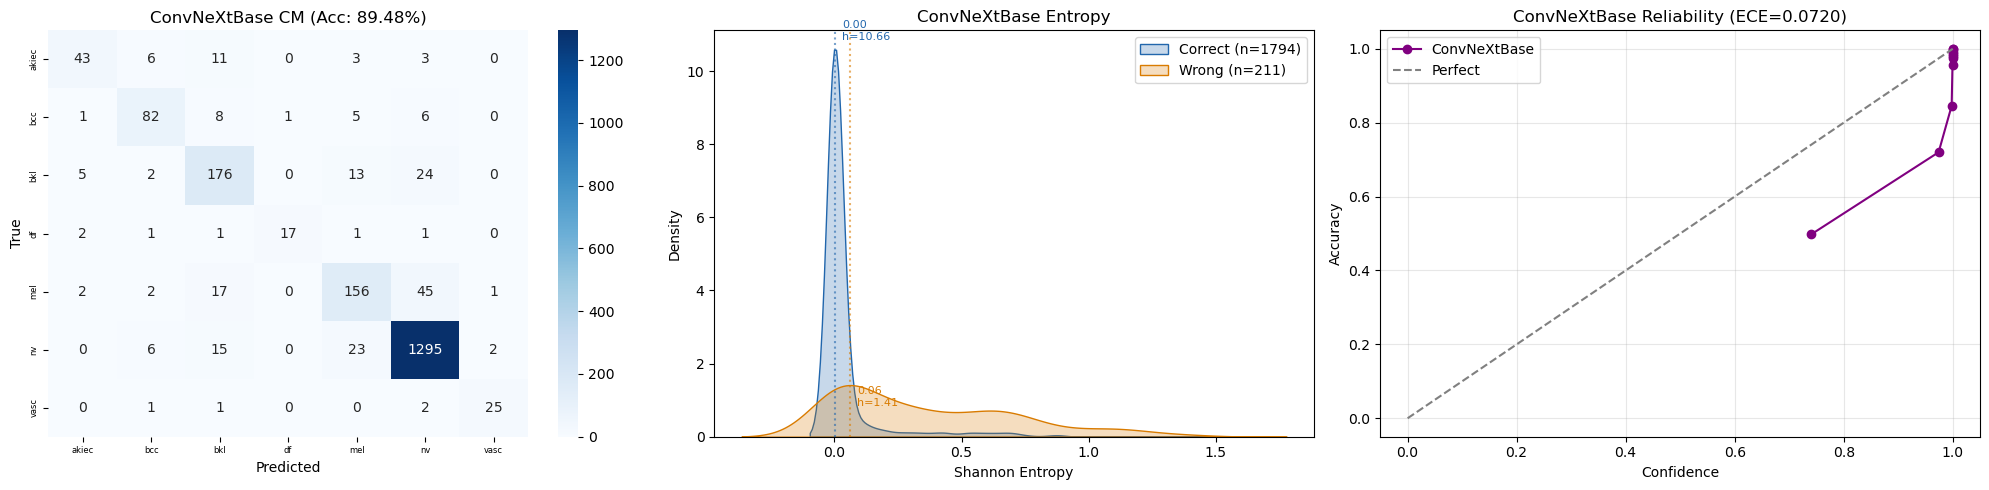


EVALUATION: ViT-Base

--- Comprehensive Metrics ---
  Accuracy: 0.9057
  AUC_macro: 0.9821
  AUC_weighted: 0.9775
  Precision_macro: 0.8824
  Precision_weighted: 0.9046
  Recall_macro: 0.8319
  Recall_weighted: 0.9057
  F1_macro: 0.8541
  F1_weighted: 0.9046
  PR_AUC_macro: 0.9039
  PR_AUC_weighted: 0.9461
  Log_Loss: 0.5066

--- Classification Report ---
              precision    recall  f1-score   support

       akiec     0.8889    0.7273    0.8000        66
         bcc     0.8519    0.8932    0.8720       103
         bkl     0.8009    0.7864    0.7936       220
          df     0.9444    0.7391    0.8293        23
         mel     0.7804    0.7489    0.7643       223
          nv     0.9451    0.9627    0.9538      1341
        vasc     0.9655    0.9655    0.9655        29

    accuracy                         0.9057      2005
   macro avg     0.8824    0.8319    0.8541      2005
weighted avg     0.9046    0.9057    0.9046      2005


--- ViT-Base Confusion Matrix (Table) ---
 

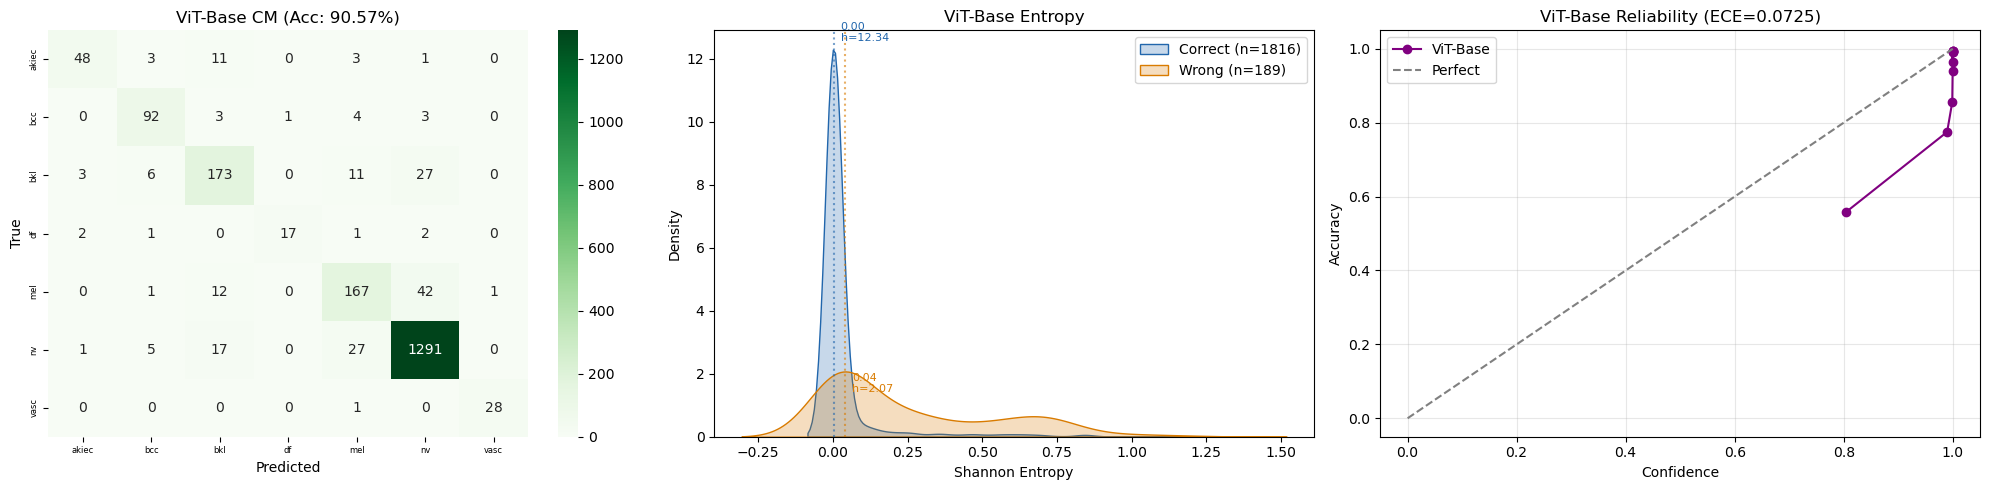


EVALUATION: EfficientNetV2M

--- Comprehensive Metrics ---
  Accuracy: 0.8808
  AUC_macro: 0.9747
  AUC_weighted: 0.9684
  Precision_macro: 0.7997
  Precision_weighted: 0.8777
  Recall_macro: 0.7988
  Recall_weighted: 0.8808
  F1_macro: 0.7919
  F1_weighted: 0.8756
  PR_AUC_macro: 0.8674
  PR_AUC_weighted: 0.9300
  Log_Loss: 0.6306

--- Classification Report ---
              precision    recall  f1-score   support

       akiec     0.8214    0.6970    0.7541        66
         bcc     0.8476    0.8641    0.8558       103
         bkl     0.7882    0.7273    0.7565       220
          df     0.7407    0.8696    0.8000        23
         mel     0.8194    0.5695    0.6720       223
          nv     0.9141    0.9679    0.9402      1341
        vasc     0.6667    0.8966    0.7647        29

    accuracy                         0.8808      2005
   macro avg     0.7997    0.7988    0.7919      2005
weighted avg     0.8777    0.8808    0.8756      2005


--- EfficientNetV2M Confusion Matrix

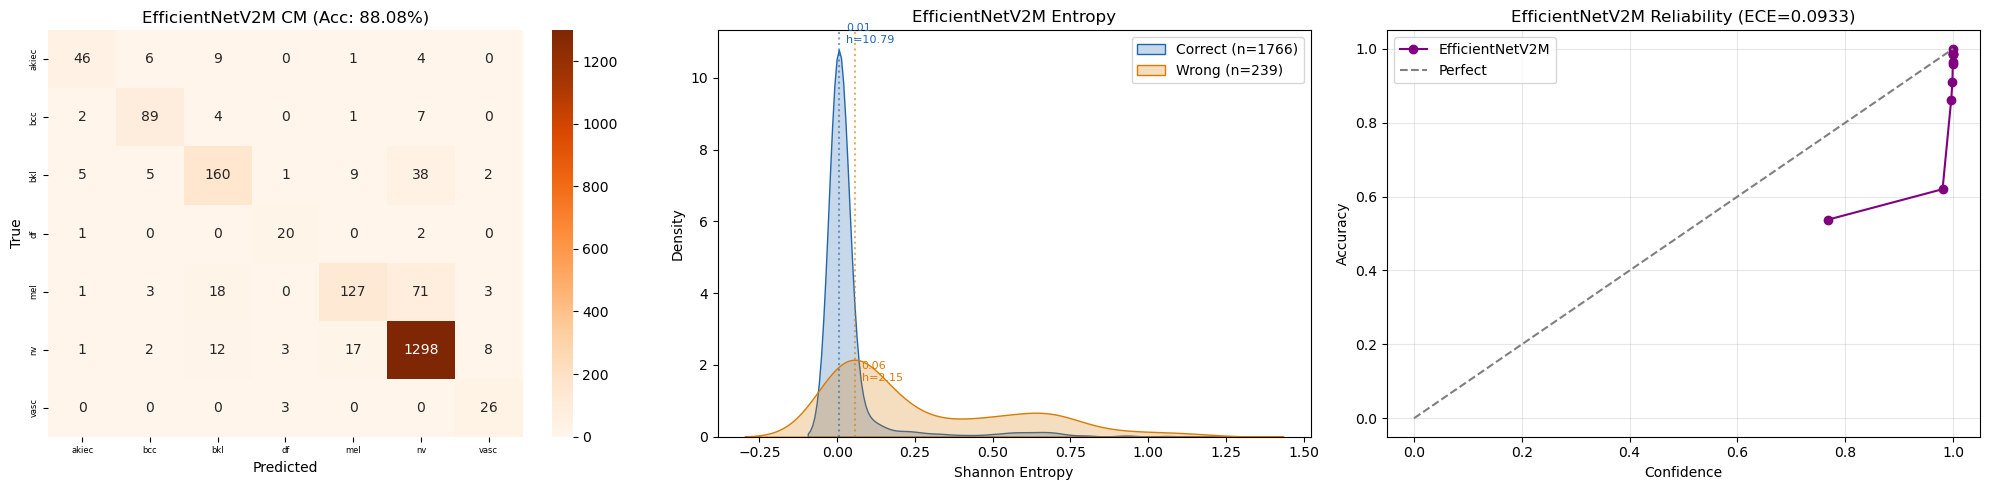


EVALUATION: InceptionResNetV2

--- Comprehensive Metrics ---
  Accuracy: 0.8274
  AUC_macro: 0.9144
  AUC_weighted: 0.9100
  Precision_macro: 0.7136
  Precision_weighted: 0.8224
  Recall_macro: 0.6260
  Recall_weighted: 0.8274
  F1_macro: 0.6555
  F1_weighted: 0.8198
  PR_AUC_macro: 0.7298
  PR_AUC_weighted: 0.8502
  Log_Loss: 0.7228

--- Classification Report ---
              precision    recall  f1-score   support

       akiec     0.8462    0.5000    0.6286        66
         bcc     0.7917    0.5534    0.6514       103
         bkl     0.7487    0.6636    0.7036       220
          df     0.6500    0.5652    0.6047        23
         mel     0.6667    0.5291    0.5900       223
          nv     0.8732    0.9500    0.9100      1341
        vasc     0.4186    0.6207    0.5000        29

    accuracy                         0.8274      2005
   macro avg     0.7136    0.6260    0.6555      2005
weighted avg     0.8224    0.8274    0.8198      2005


--- InceptionResNetV2 Confusion Ma

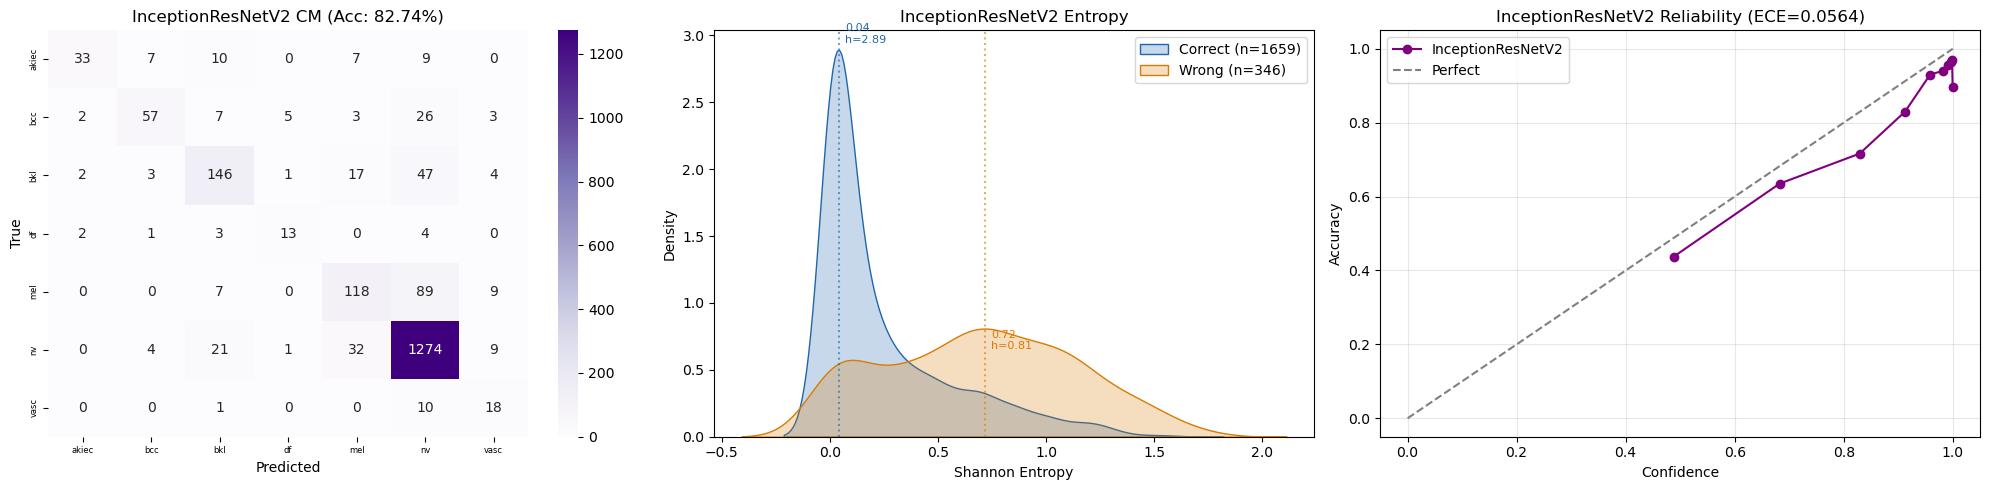


EVALUATION: SoftVoting

--- Comprehensive Metrics ---
  Accuracy: 0.9092
  AUC_macro: 0.9877
  AUC_weighted: 0.9824
  Precision_macro: 0.9054
  Precision_weighted: 0.9070
  Recall_macro: 0.8331
  Recall_weighted: 0.9092
  F1_macro: 0.8651
  F1_weighted: 0.9064
  PR_AUC_macro: 0.9222
  PR_AUC_weighted: 0.9582
  Log_Loss: 0.2760

--- Classification Report ---
              precision    recall  f1-score   support

       akiec     0.9038    0.7121    0.7966        66
         bcc     0.8725    0.8641    0.8683       103
         bkl     0.8186    0.8000    0.8092       220
          df     1.0000    0.8261    0.9048        23
         mel     0.8453    0.6861    0.7574       223
          nv     0.9318    0.9776    0.9541      1341
        vasc     0.9655    0.9655    0.9655        29

    accuracy                         0.9092      2005
   macro avg     0.9054    0.8331    0.8651      2005
weighted avg     0.9070    0.9092    0.9064      2005


--- SoftVoting Confusion Matrix (Table) -

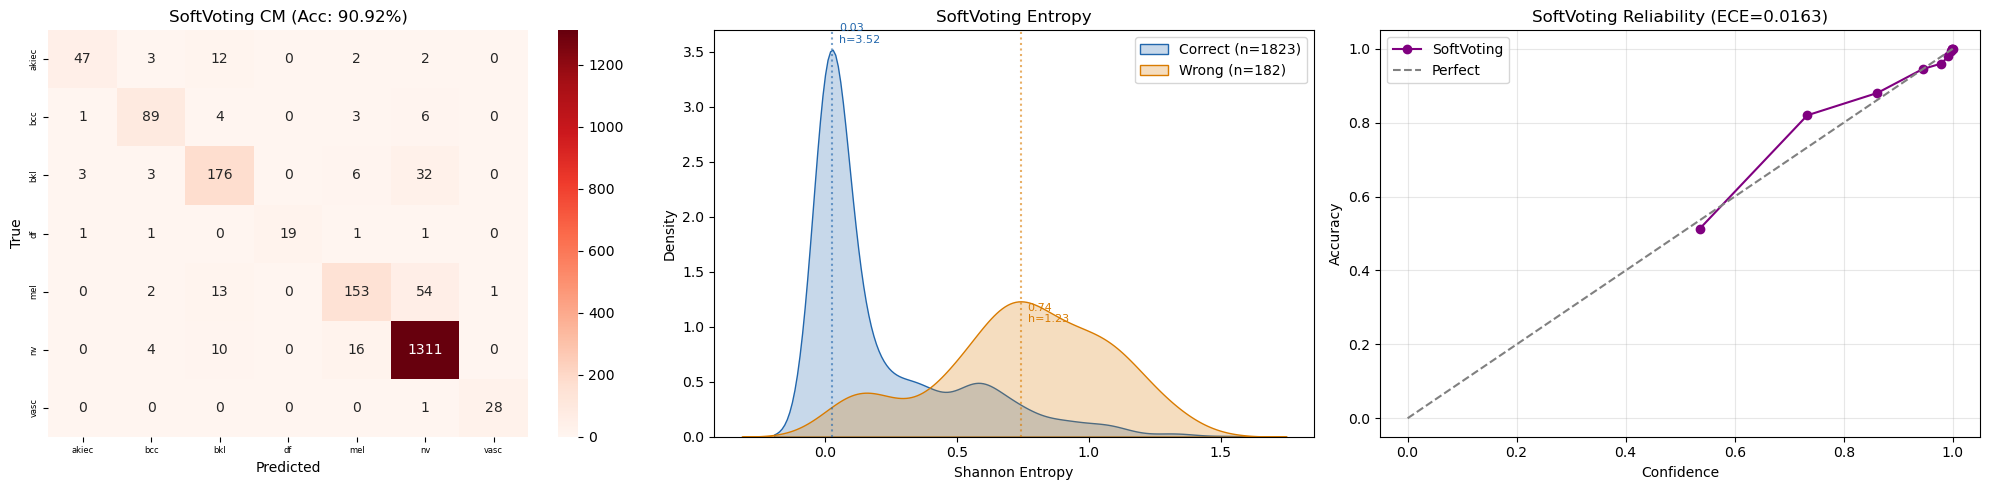


EVALUATION: RigorousStacking

--- Comprehensive Metrics ---
  Accuracy: 0.9167
  AUC_macro: 0.9801
  AUC_weighted: 0.9774
  Precision_macro: 0.9043
  Precision_weighted: 0.9155
  Recall_macro: 0.8487
  Recall_weighted: 0.9167
  F1_macro: 0.8729
  F1_weighted: 0.9153
  PR_AUC_macro: 0.9182
  PR_AUC_weighted: 0.9531
  Log_Loss: 0.3000

--- Classification Report ---
              precision    recall  f1-score   support

       akiec     0.9057    0.7273    0.8067        66
         bcc     0.8667    0.8835    0.8750       103
         bkl     0.8198    0.8273    0.8235       220
          df     1.0000    0.7826    0.8780        23
         mel     0.8227    0.7489    0.7840       223
          nv     0.9483    0.9717    0.9599      1341
        vasc     0.9667    1.0000    0.9831        29

    accuracy                         0.9167      2005
   macro avg     0.9043    0.8487    0.8729      2005
weighted avg     0.9155    0.9167    0.9153      2005


--- RigorousStacking Confusion Matr

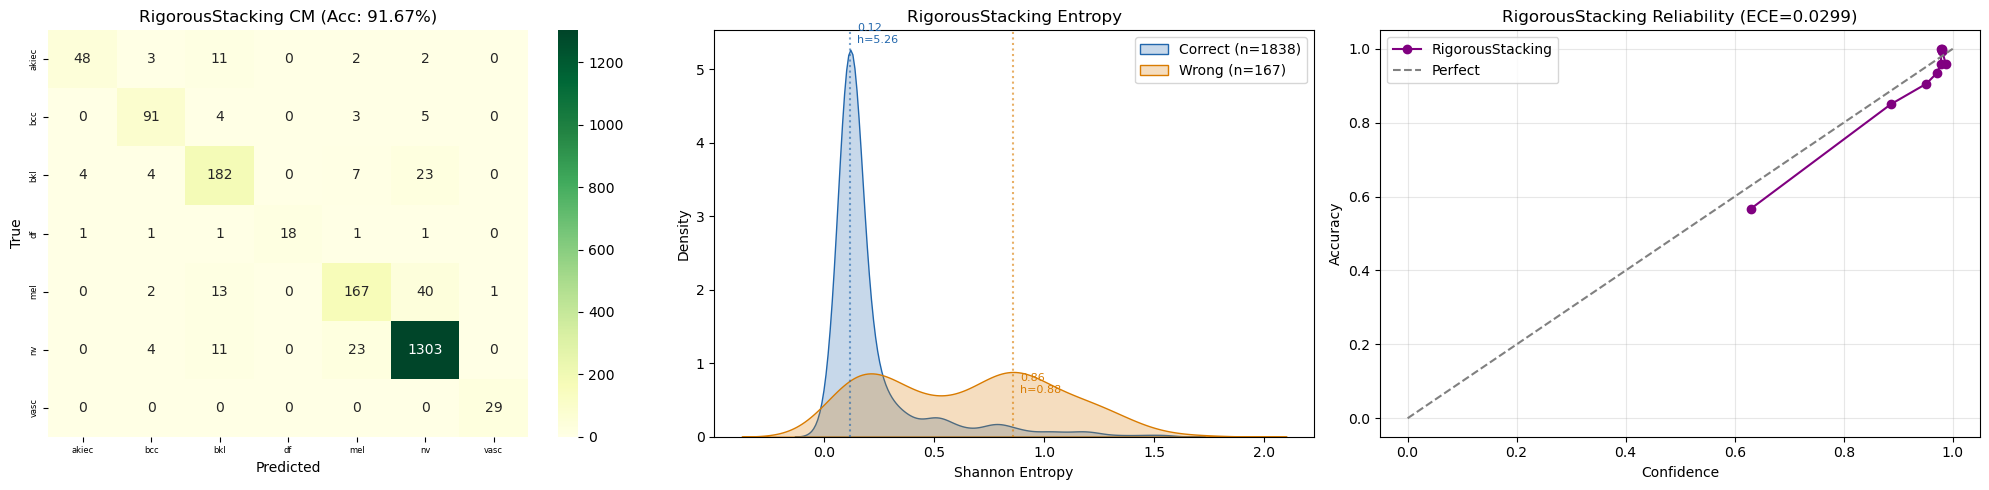

In [8]:
COLORS = {
    'ConvNeXtBase': 'Blues', 'ViT-Base': 'Greens',
    'EfficientNetV2M': 'Oranges', 'InceptionResNetV2': 'Purples',
    'SoftVoting': 'Reds', 'RigorousStacking': 'YlGn'
}

all_results = {}
all_metrics_list = []

# Build complete predictions dict
all_probs = dict(test_preds)
all_probs['SoftVoting'] = soft_voting_probs
all_probs['RigorousStacking'] = stacking_probs

for model_name in INDIVIDUAL_MODELS + ['SoftVoting', 'RigorousStacking']:
    res = evaluate_model(all_probs[model_name], y_true_flat, y_true_cat,
                         model_name, CLASS_NAMES, CLASS_NAMES_4CM, color=COLORS[model_name])
    all_results[model_name] = res
    all_metrics_list.append(res['metrics'])

## Summary Tables

In [9]:
print(f"\n{'='*90}\nFINAL COMPARISON: {DATASET.upper()}\n{'='*90}")

summary_df = pd.DataFrame(all_metrics_list)
print("\n--- Full Metrics Comparison ---")
print(summary_df.to_string(index=False))

summary_df.to_csv(f"{OUTPUT_DIR}/{DATASET}_summary_metrics.csv", index=False)

compact = summary_df[['Model', 'Accuracy', 'AUC_macro', 'F1_macro',
                       'Precision_macro', 'Recall_macro', 'PR_AUC_macro']].copy()
compact.columns = ['Model', 'Accuracy', 'AUC', 'F1', 'Precision', 'Recall', 'PR-AUC']
print("\n--- Compact Table for Paper ---")
print(compact.to_string(index=False))
compact.to_csv(f"{OUTPUT_DIR}/{DATASET}_compact_metrics.csv", index=False)


FINAL COMPARISON: DERMAMNIST

--- Full Metrics Comparison ---
            Model  Accuracy  AUC_macro  AUC_weighted  Precision_macro  Precision_weighted  Recall_macro  Recall_weighted  F1_macro  F1_weighted  PR_AUC_macro  PR_AUC_weighted  Log_Loss
     ConvNeXtBase  0.894763   0.982024      0.977076         0.850633            0.892688      0.787726         0.894763  0.815729     0.892920      0.893371         0.945111  0.512868
         ViT-Base  0.905736   0.982096      0.977452         0.882442            0.904603      0.831869         0.905736  0.854075     0.904637      0.903940         0.946132  0.506589
  EfficientNetV2M  0.880798   0.974730      0.968430         0.799725            0.877702      0.798840         0.880798  0.791896     0.875625      0.867434         0.930039  0.630615
InceptionResNetV2  0.827431   0.914384      0.910013         0.713573            0.822356      0.626018         0.827431  0.655467     0.819783      0.729811         0.850213  0.722803
       SoftV

## Publication Figure

In [10]:

ROW_LETTERS = list("abcdef")
CORRECT_COLOR_FIG = "#2166AC"
WRONG_COLOR_FIG = "#D97B00"

MODELS_FIG = [
    ("ConvNeXtBase",      "ConvNeXt-Base",      "Oranges", "darkorange"),
    ("ViT-Base",          "ViT-Base",           "Oranges", "darkorange"),
    ("EfficientNetV2M",   "EfficientNetV2-M",   "Oranges", "darkorange"),
    ("InceptionResNetV2", "InceptionResNetV2",  "Oranges", "darkorange"),
    ("SoftVoting",        "Soft Voting",        "Blues",   "#2166AC"),
    ("RigorousStacking",  "Rigorous Stacking",  "Greens",  "#1B7837"),
]

SHOW_PEAK_MARKERS = False  # Set True to add peak lines on entropy plots in pub figure


def plot_row_pub(fig, gs_row, model_key, cmap, line_color, row_idx, font_scale=1.0):
    probs = all_probs[model_key]
    y_pred_row = np.argmax(probs, axis=1)
    acc = accuracy_score(y_true_flat, y_pred_row)
    letter = ROW_LETTERS[row_idx]

    # Panel (1): Confusion Matrix
    ax0 = fig.add_subplot(gs_row[0])
    cm = confusion_matrix(y_true_flat, y_pred_row)
    sns.heatmap(cm, annot=True, fmt="d", cmap=cmap, ax=ax0, cbar=False,
                annot_kws={"size": 5.0 * font_scale}, linewidths=0.08,
                xticklabels=np.arange(n_classes), yticklabels=np.arange(n_classes))
    ax0.set_yticklabels(ax0.get_yticklabels(), rotation=0)
    ax0.set_xlabel("Predicted Label")
    ax0.set_ylabel("True Label")
    ax0.tick_params(axis="both", pad=1)
    ax0.set_title(f"{letter}(1)   Acc = {acc:.2%}",
                  fontsize=7 * font_scale, fontweight="bold", loc="left", pad=3)

    # Panel (2): Entropy Distribution (with optional peak markers)
    ax1 = fig.add_subplot(gs_row[1])
    entropy = -np.sum(probs * np.log(probs + 1e-9), axis=1)
    correct = (y_pred_row == y_true_flat)
    sns.kdeplot(entropy[correct], fill=True, color=CORRECT_COLOR_FIG,
                alpha=0.55, ax=ax1, label="Correct", linewidth=0.6)
    sns.kdeplot(entropy[~correct], fill=True, color=WRONG_COLOR_FIG,
                alpha=0.55, ax=ax1, label="Incorrect", linewidth=0.6)
    
    if SHOW_PEAK_MARKERS and (~correct).sum() > 0:
        # Use the FIXED peak detection for visualization
        analysis = analyze_entropy_peaks(entropy[correct], entropy[~correct],
                                         f"Fig_{model_key}", n_points=500)
        if analysis:
            # Mark top peak only for each distribution to keep figure clean
            if analysis['peaks_correct_x']:
                ax1.axvline(analysis['peaks_correct_x'][0], color=CORRECT_COLOR_FIG,
                           linestyle=':', alpha=0.6, linewidth=0.5)
            if analysis['peaks_wrong_x']:
                ax1.axvline(analysis['peaks_wrong_x'][0], color=WRONG_COLOR_FIG,
                           linestyle=':', alpha=0.6, linewidth=0.5)
    
    ax1.set_xlabel("Entropy")
    ax1.set_ylabel("Density")
    ax1.legend(loc="upper right", frameon=False)
    ax1.tick_params(axis="both", pad=1)
    for spine in ax1.spines.values():
        spine.set_linewidth(0.4)
    ax1.set_title(f"{letter}(2)", fontsize=7 * font_scale,
                  fontweight="bold", loc="left", pad=3)

    # Panel (3): Reliability Diagram
    ax2 = fig.add_subplot(gs_row[2])
    is_correct = correct.astype(int)
    conf = np.max(probs, axis=1)
    p_true, p_pred = calibration_curve(is_correct, conf, n_bins=10, strategy="quantile")
    ax2.plot(p_pred, p_true, marker="o", markersize=1.5,
             lw=0.7, color=line_color, clip_on=False)
    ax2.plot([0, 1], [0, 1], "--", color="gray", lw=0.6)
    ax2.set_xlabel("Confidence")
    ax2.set_ylabel("Accuracy")
    ax2.set_xlim(-0.05, 1.05)
    ax2.set_ylim(-0.05, 1.05)
    ax2.tick_params(axis="both", pad=1)
    for spine in ax2.spines.values():
        spine.set_linewidth(0.4)
    ax2.set_title(f"{letter}(3)", fontsize=7 * font_scale,
                  fontweight="bold", loc="left", pad=3)


def generate_publication_figure(output_format='png', dpi=1200):
    if output_format == 'png':
        fig_w, fig_h = 6.85, 8.94
        font_scale = 1.0
        font_size = 7
    else:
        fig_w, fig_h = 18, 23.5
        font_scale = 1.6
        font_size = 11
    
    plt.rcParams.update({
        "font.family": "Arial",
        "font.size": font_size,
        "axes.titlesize": font_size,
        "axes.labelsize": font_size - 0.5,
        "xtick.labelsize": font_size - 1.5,
        "ytick.labelsize": font_size - 1.5,
        "legend.fontsize": font_size - 1.5,
        "axes.linewidth": 0.4 * font_scale,
        "xtick.major.width": 0.4 * font_scale,
        "ytick.major.width": 0.4 * font_scale,
    })
    
    fig = plt.figure(figsize=(fig_w, fig_h), dpi=dpi)
    gs_outer = gridspec.GridSpec(
        6, 1, figure=fig,
        hspace=0.55 if output_format == 'png' else 0.35,
        top=0.98, bottom=0.03 if output_format == 'png' else 0.02,
        left=0.10 if output_format == 'png' else 0.07,
        right=0.98
    )
    
    for i, (m_key, _, cmap, color) in enumerate(MODELS_FIG):
        gs_inner = gridspec.GridSpecFromSubplotSpec(1, 3, subplot_spec=gs_outer[i], wspace=0.28)
        plot_row_pub(fig, gs_inner, m_key, cmap, color, i, font_scale)
    
    ext = 'png' if output_format == 'png' else 'tif'
    output_path = f"{OUTPUT_DIR}/Fig{FIGURE_NUMBER}.{ext}"
    plt.savefig(output_path, bbox_inches="tight",
                pad_inches=0.05 if output_format == 'png' else 0.1,
                dpi=dpi, format=output_format,
                metadata={"Software": "matplotlib"} if output_format == 'png' else None)
    plt.close(fig)
    print(f"Saved {output_path}")
    return output_path

png_path = generate_publication_figure(output_format='png', dpi=1200)
tiff_path = generate_publication_figure(output_format='tiff', dpi=600)

print(f"\n✓ Publication figures:")
print(f"  PNG (1200 DPI): {png_path}")
print(f"  TIFF (600 DPI): {tiff_path}")

Saved ./dermamnist_results/Fig5.png
Saved ./dermamnist_results/Fig5.tif

✓ Publication figures:
  PNG (1200 DPI): ./dermamnist_results/Fig5.png
  TIFF (600 DPI): ./dermamnist_results/Fig5.tif
